# 04 · Thermal cascade on the IEEE 39-bus system
*Companion to* **Biggest Power Grid Failures: Engineering Analysis of History's Most Severe Blackouts, Cascades, and Grid Failures** *by Ganesh Kumar Pandey.* See **Chapter 2, Section 2.5 (Figure 2.3)**, **Chapter 5** (Northeast 2003) and
**Chapter 18, Section 18.2.1** (operation close to limits).

The IEEE 39-bus "New England" test system is a standard 10-machine, 345 kV benchmark. We run the
overload -> trip -> redistribute loop from Figure 2.3 with a DC power flow:

1. trip one branch, 2. re-solve flows, 3. trip the most overloaded branch (protection doing its job on its
own element), 4. rebalance any islands (shed load if an island lacks generation), 5. repeat.

Relays trip at 120 % of the normal rating (a stand-in for an emergency rating).

> **Model note.** This is a simplified teaching model. Parameters are chosen to be plausible and to reproduce the *shape* of the reported event, not to replicate any operator's measured data. For the authoritative record, read the official report cited in the book. A DC flow captures the thermal cascade but ignores voltage collapse; see notebook 05 for that.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from gridfail import plotstyle as ps
ps.apply()
FIG = os.path.abspath(os.path.join('..', 'figures'))

In [2]:
from gridfail.cascade import load_case39, cascade, n1_screen

TRIP = 1.2
sys39 = load_case39(load_scale=1.1)
r = cascade(sys39, ['L21-22'], trip_margin=TRIP)
total = sys39['load'].sum()
print(f"Initiating outage: line 21-22, system load {total:.0f} MW (110 % of base)\n")
print(f"{'step':>4s}  {'tripped':10s} {'loading at trip':>16s} {'load served':>12s}")
for s in r['steps']:
    tl = ', '.join(f'{x*100:.0f}%' for x in s.get('trip_loading', [])) or '(initiating)'
    print(f"{s['step']:4d}  {', '.join(s['tripped']):10s} {tl:>16s} {s['served']:10.0f} MW")
print(f"\nLoad lost: {r['load_lost_mw']:.0f} MW ({r['load_lost_pct']:.1f} %), branches tripped by protection: {r['n_tripped']}")

Initiating outage: line 21-22, system load 6880 MW (110 % of base)

step  tripped     loading at trip  load served
   0  L21-22         (initiating)       6880 MW
   1  L23-24                 166%       6372 MW
   2  L2-3                   176%       6372 MW
   3  L26-27                 179%       6372 MW
   4  L1-2                   267%       4841 MW

Load lost: 2039 MW (29.6 %), branches tripped by protection: 4


## Operation close to limits: the cliff edge

Now screen **every** possible single initiating outage (all 46 lines and transformers), at increasing
system stress. Chapter 18 argues that margin, not the initiating event, decides whether a fault stays local.

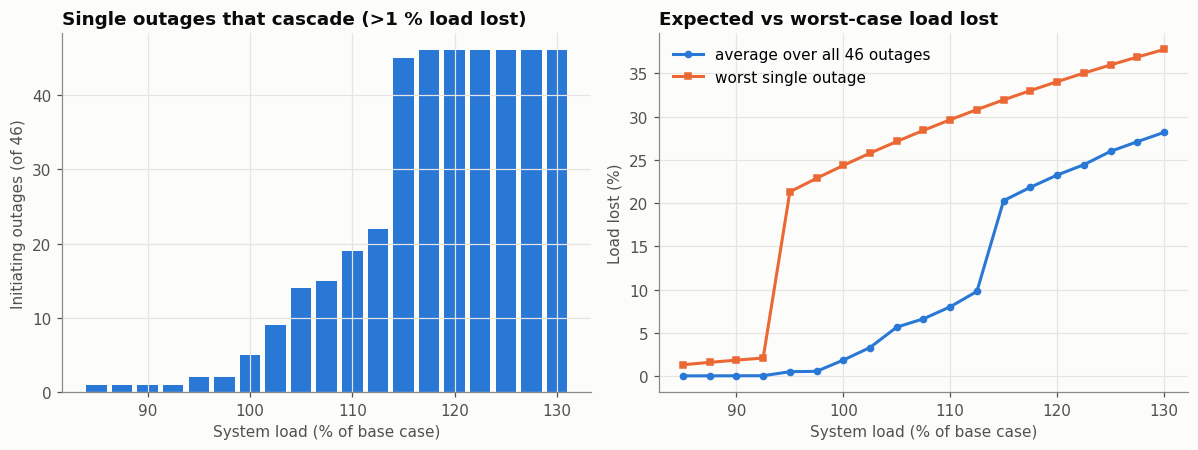

load  85.0 %   cascading outages  1/46   mean load lost   0.0 %
load  87.5 %   cascading outages  1/46   mean load lost   0.0 %
load  90.0 %   cascading outages  1/46   mean load lost   0.0 %
load  92.5 %   cascading outages  1/46   mean load lost   0.0 %
load  95.0 %   cascading outages  2/46   mean load lost   0.5 %
load  97.5 %   cascading outages  2/46   mean load lost   0.6 %
load 100.0 %   cascading outages  5/46   mean load lost   1.9 %
load 102.5 %   cascading outages  9/46   mean load lost   3.3 %
load 105.0 %   cascading outages 14/46   mean load lost   5.7 %
load 107.5 %   cascading outages 15/46   mean load lost   6.6 %
load 110.0 %   cascading outages 19/46   mean load lost   8.0 %
load 112.5 %   cascading outages 22/46   mean load lost   9.8 %
load 115.0 %   cascading outages 45/46   mean load lost  20.3 %
load 117.5 %   cascading outages 46/46   mean load lost  21.8 %
load 120.0 %   cascading outages 46/46   mean load lost  23.2 %
load 122.5 %   cascading outages 46/46  

In [3]:
import warnings; warnings.filterwarnings('ignore')
scales = np.round(np.arange(0.85, 1.31, 0.025), 3)
mean_lost, n_casc, worst = [], [], []
for ls in scales:
    res = n1_screen(load_case39(load_scale=ls), trip_margin=TRIP)
    pct = np.array([x[3] for x in res])
    mean_lost.append(pct.mean()); n_casc.append((pct > 1).sum()); worst.append(pct.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.bar(scales * 100, n_casc, width=2.0, color=ps.SERIES[0])
ax1.set_xlabel('System load (% of base case)'); ax1.set_ylabel('Initiating outages (of 46)')
ax1.set_title('Single outages that cascade (>1 % load lost)')
ax2.plot(scales * 100, mean_lost, color=ps.SERIES[0], marker='o', ms=4, label='average over all 46 outages')
ax2.plot(scales * 100, worst, color=ps.SERIES[1], marker='s', ms=4, label='worst single outage')
ax2.set_xlabel('System load (% of base case)'); ax2.set_ylabel('Load lost (%)')
ax2.set_title('Expected vs worst-case load lost'); ax2.legend(loc='upper left')
fig.tight_layout()
fig.savefig(os.path.join(FIG, '04_cascade_cliff.png'))
plt.show()

for ls, n, m in zip(scales, n_casc, mean_lost):
    print(f"load {ls*100:5.1f} %   cascading outages {n:2d}/46   mean load lost {m:5.1f} %")

**Reading the result.** Below about base load almost no single outage spreads. A few percent more load
and the number of dangerous initiating events jumps sharply: the same tree contact that is harmless at
90 % loading takes out a large share of the system at 115 %. Beyond roughly 113 % the intact network
already has a branch above the relay threshold, so the cascade no longer even needs a trigger. This is India 2012 (chronic overdrawl) and
Ohio 2003 (lines near thermal limits on a summer afternoon) in one chart.

**Try it:** set `trip_margin=1.0` (relays at normal rating) or `rating_scale=1.2` in `load_case39`
(reconductoring) and rerun the screen.